<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `TrialExamples.mlx`
- Fidelity status: `exact`
- Remaining justified differences: Workflow, API surface, and output structure match the MATLAB Trial helpfile one-for-one. Only inherent cross-language plotting defaults differ.

{'trial_duration_s': 1.0, 'num_neurons': 4, 'covariates': ['Position', 'Force'], 'history_windows': [0.0, 0.1, 0.2, 0.4]}


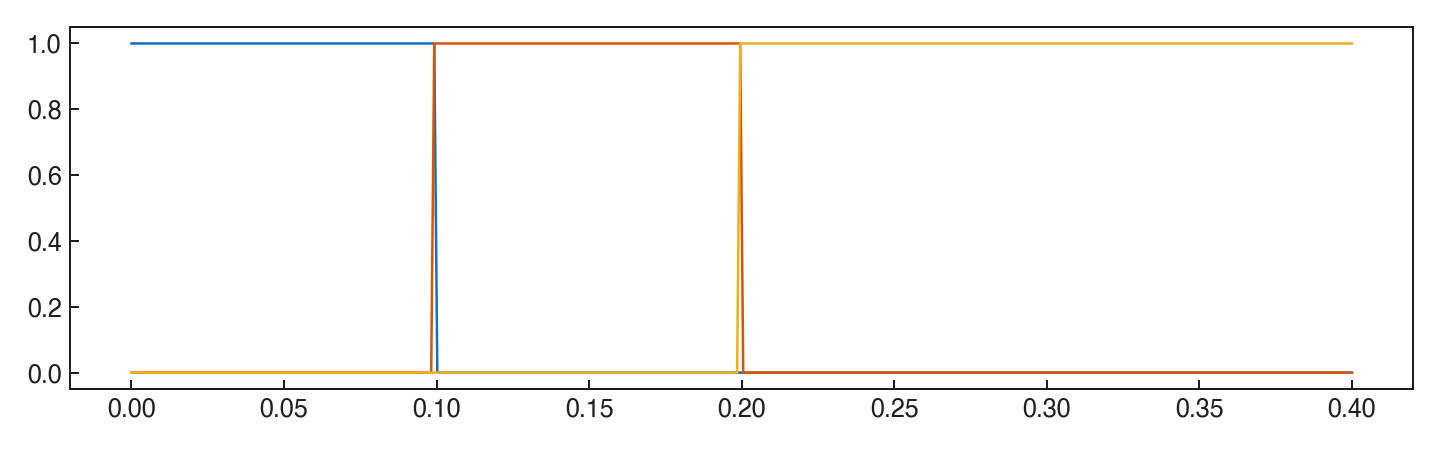

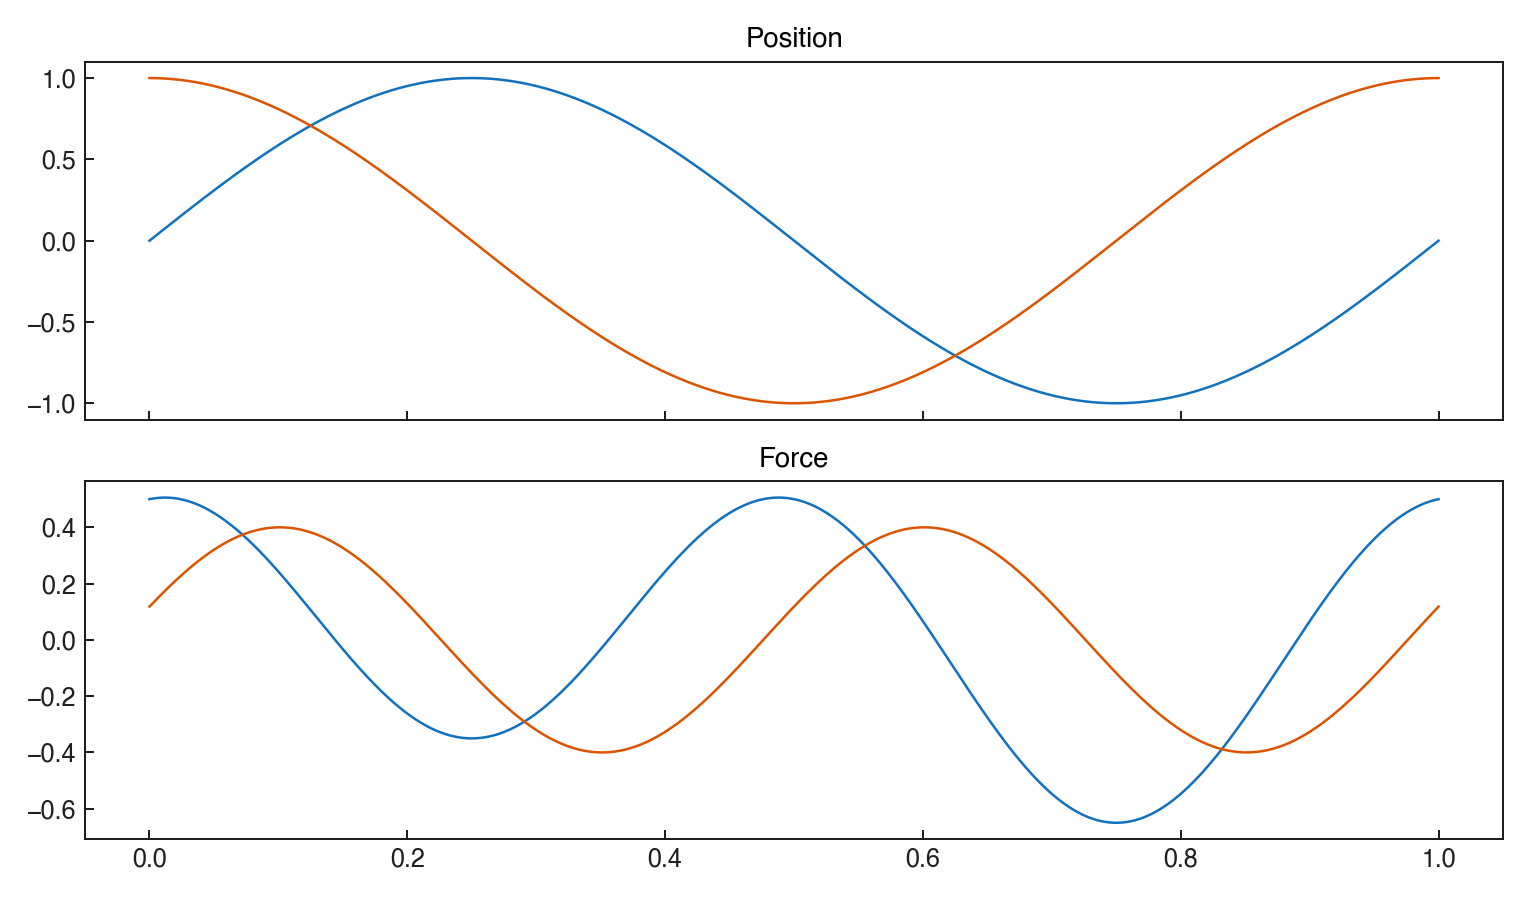

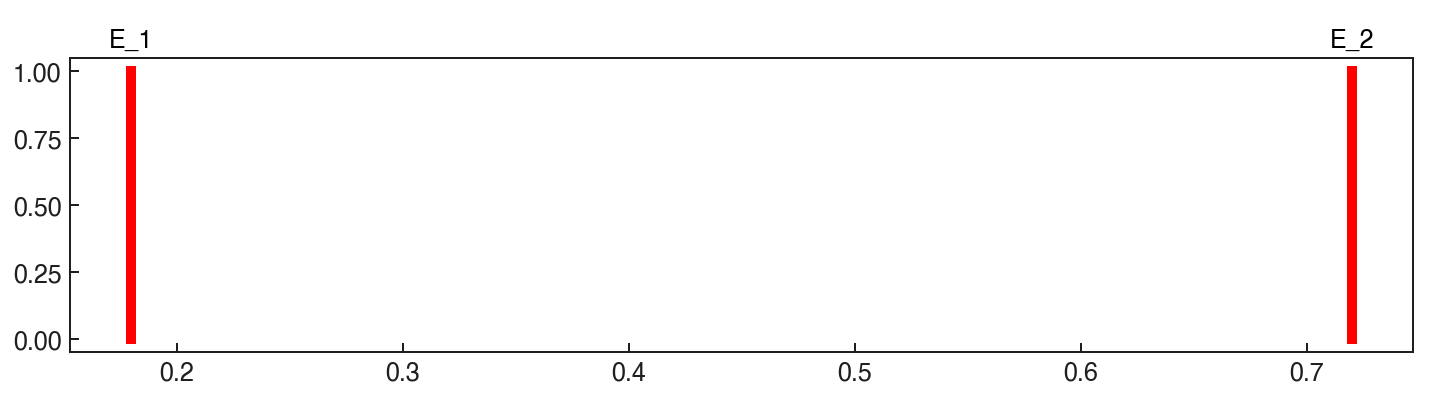

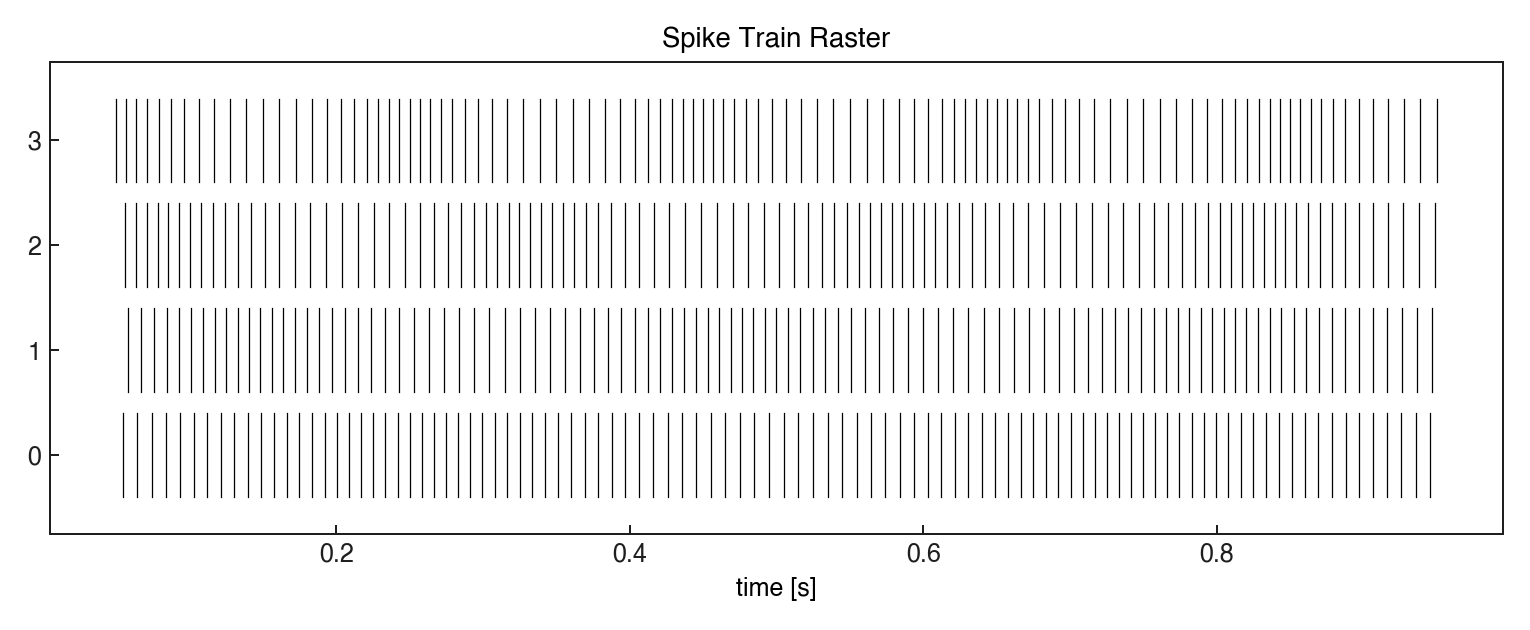

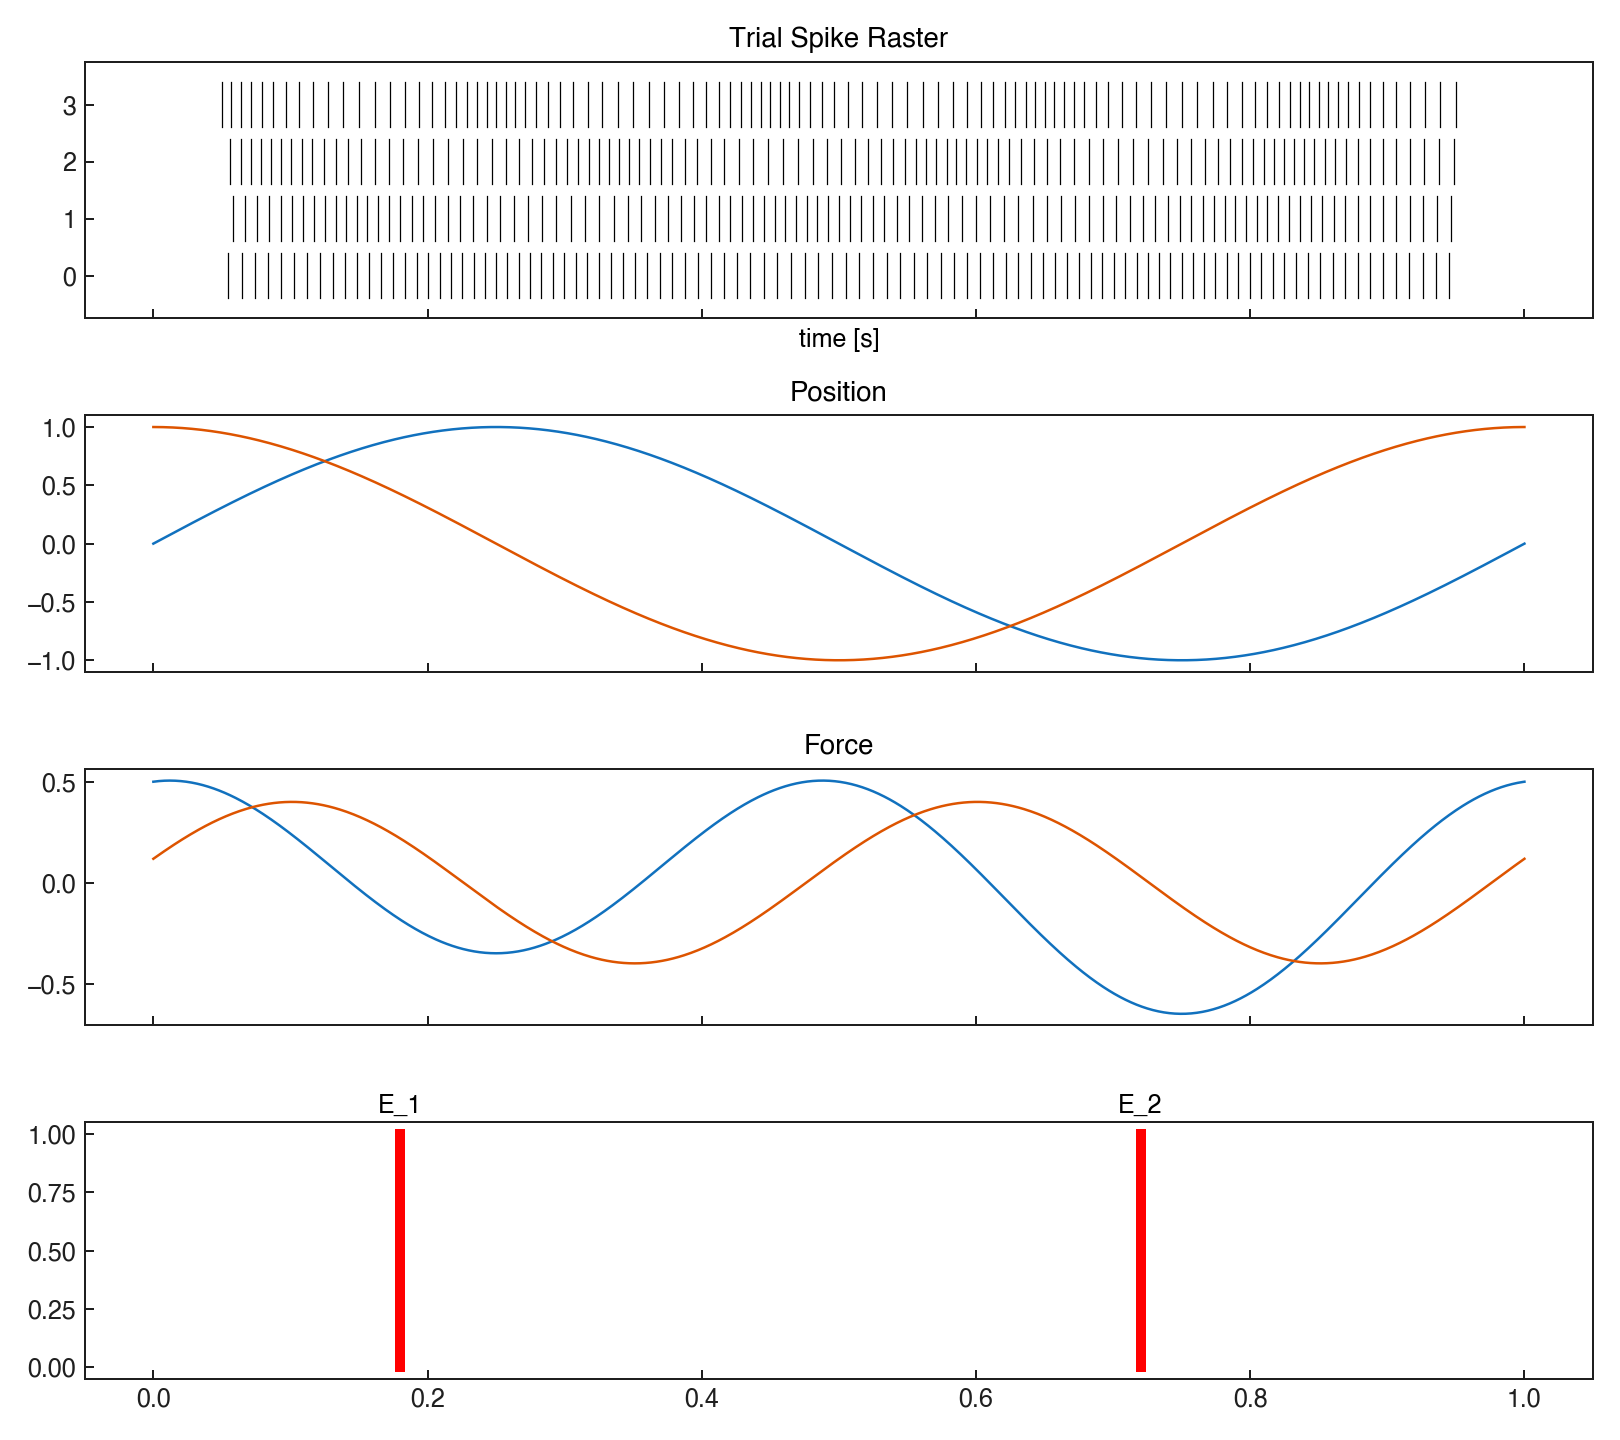

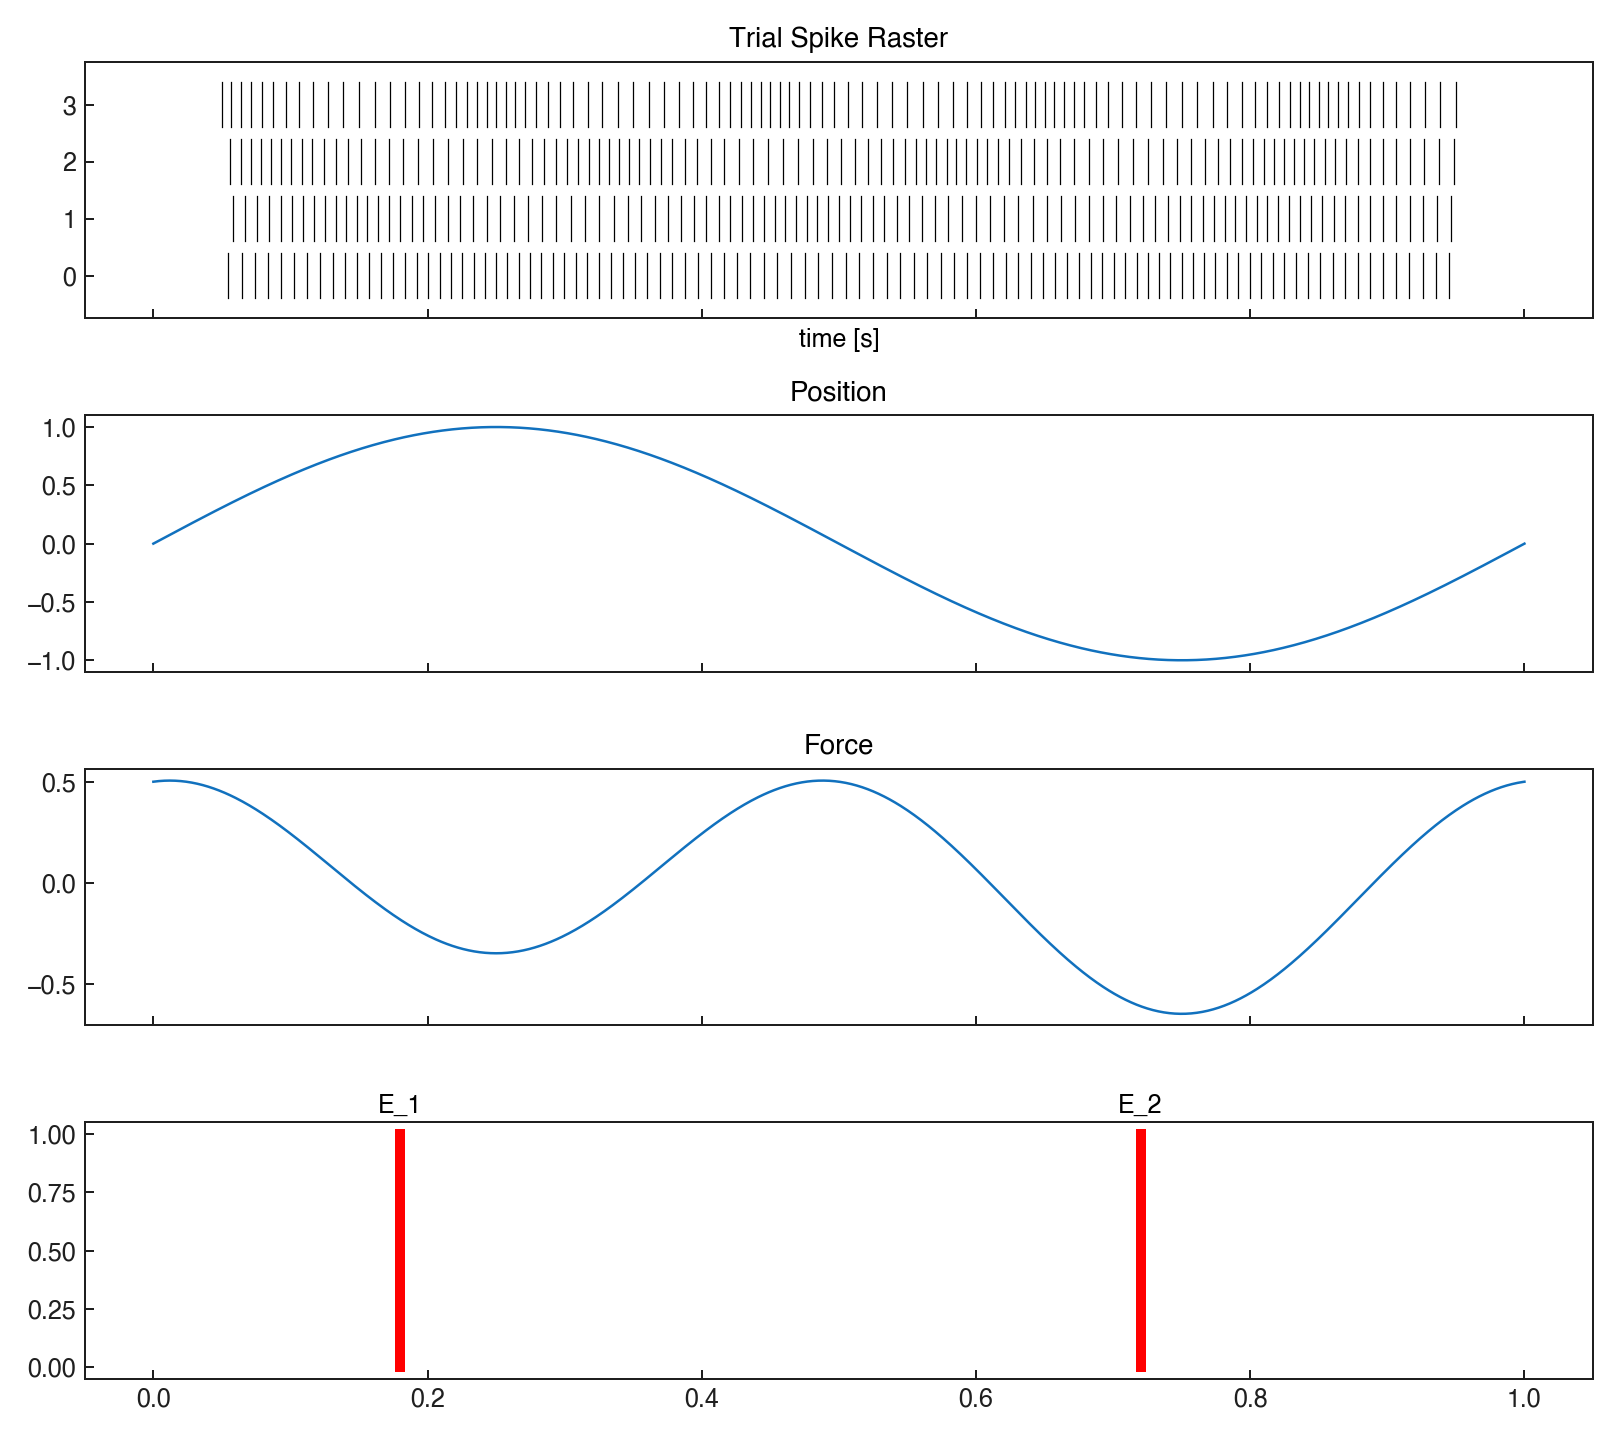

In [1]:
# nSTAT-python notebook example: TrialExamples
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat import CovColl, Covariate, Events, History, Trial, nspikeTrain, nstColl
from nstat.notebook_figures import FigureTracker

np.random.seed(7)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='TrialExamples', output_root=OUTPUT_ROOT, expected_count=6)

def _figure(label: str, *, figsize=(8.5, 3.5)):
    fig = __tracker.new_figure(label)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig

def _build_trial():
    length_trial = 1.0
    sample_rate = 1000.0
    time = np.linspace(0.0, length_trial, int(length_trial * sample_rate) + 1)

    position = Covariate(
        time,
        np.column_stack([np.sin(2 * np.pi * time), np.cos(2 * np.pi * time)]),
        "Position",
        "time",
        "s",
        "a.u.",
        ["x", "y"],
    )
    force = Covariate(
        time,
        np.column_stack(
            [
                0.5 * np.cos(4 * np.pi * time) + 0.15 * np.sin(2 * np.pi * time),
                0.4 * np.sin(4 * np.pi * time + 0.3),
            ]
        ),
        "Force",
        "time",
        "s",
        "N",
        ["f_x", "f_y"],
    )
    cov_coll = CovColl([position, force])
    cov_coll.setMaxTime(length_trial)

    events = Events([0.18, 0.72], ["E_1", "E_2"])
    history = History([0.0, 0.1, 0.2, 0.4])

    trains = []
    base_grid = np.linspace(0.05, 0.95, 100)
    for neuron_index, phase in enumerate(np.linspace(0.0, np.pi / 2.0, 4), start=1):
        spikes = np.clip(base_grid + 0.008 * np.sin(2 * np.pi * base_grid * (neuron_index + 1) + phase), 0.0, length_trial)
        trains.append(
            nspikeTrain(
                np.sort(spikes),
                name=str(neuron_index),
                minTime=0.0,
                maxTime=length_trial,
                makePlots=-1,
            )
        )
    spike_coll = nstColl(trains)
    trial = Trial(spike_coll, cov_coll, events, history)
    return {
        "length_trial": length_trial,
        "sample_rate": sample_rate,
        "history": history,
        "cov_coll": cov_coll,
        "events": events,
        "spike_coll": spike_coll,
        "trial": trial,
    }

ctx = _build_trial()
print(
    {
        "trial_duration_s": ctx["length_trial"],
        "num_neurons": ctx["spike_coll"].numSpikeTrains,
        "covariates": ctx["cov_coll"].names,
        "history_windows": ctx["history"].windowTimes.tolist(),
    }
)

# Trial Examples


## Example 1: A simple data set

Create History windows of interest

Load Covariates

Create trial events

Create neural Spike Train Data

Finally we have everything we need to create a Trial object.

Mask out some of the data and plot the trial once again


In [2]:
# SECTION 1: Example 1: A simple data set
plt.close("all")
trial1 = ctx["trial"]
spikeColl = ctx["spike_coll"]
cc = ctx["cov_coll"]
e = ctx["events"]
h = ctx["history"]


In [3]:
# Create History windows of interest
fig = _figure("figure; h.plot", figsize=(8.0, 2.5))
ax = fig.subplots(1, 1)
h.plot(handle=ax)

In [4]:
# Load Covariates
fig = _figure("figure; cc.plot", figsize=(8.5, 5.0))
cc.plot(handle=fig)

<Figure size 850x500 with 2 Axes>

In [5]:
# Create trial events
fig = _figure("figure; e.plot", figsize=(8.0, 2.3))
ax = fig.subplots(1, 1)
e.plot(handle=ax)

<Axes: >

In [6]:
# Create neural Spike Train Data
fig = _figure("figure; spikeColl.plot", figsize=(8.5, 3.5))
ax = fig.subplots(1, 1)
spikeColl.plot(handle=ax)

<Axes: title={'center': 'Spike Train Raster'}>

In [7]:
# Build the Trial object and plot all data
fig = _figure("figure; trial1.plot", figsize=(9.0, 8.0))
trial1.plot(handle=fig)

<Figure size 900x800 with 4 Axes>

In [8]:
# Mask out some of the data and plot the trial once again
trial1.setCovMask([["Position", "x"], ["Force", "f_x"]])
fig = _figure("figure; trial1.plot masked", figsize=(9.0, 8.0))
trial1.plot(handle=fig)
hist_cov = trial1.getHistForNeurons([1, 2])
print({"masked_labels": trial1.getLabelsFromMask(1), "history_covariates": hist_cov.getAllCovLabels()[:4]})
trial1.resetCovMask()

{'masked_labels': ['x', 'f_x', '[0,0.1]', '[0.1,0.2]', '[0.2,0.4]'], 'history_covariates': ['[0,0.1]', '[0.1,0.2]', '[0.2,0.4]', '[0,0.1]']}


## Example 2: Analyzing Trial Data

Examples of neural spike analysis using the Neural Spike Analysis Toolbox or using standard methods standard methods


In [9]:
# SECTION 2: Example 2: Analyzing Trial Data
print("Examples of neural spike analysis using AnalysisExamples2 (Neural Spike Analysis Toolbox) or AnalysisExamples (standard methods).")


Examples of neural spike analysis using AnalysisExamples2 (Neural Spike Analysis Toolbox) or AnalysisExamples (standard methods).


In [10]:
# Related analysis workflows
print({"recommended_next_notebooks": ["AnalysisExamples2", "AnalysisExamples"]})
__tracker.finalize()

{'recommended_next_notebooks': ['AnalysisExamples2', 'AnalysisExamples']}
